In [1]:
# Importación de librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Scikit-Learn para procesamiento y métricas
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow y Keras para la Red Neuronal
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuración de estilo para las gráficas
sns.set_theme(style="whitegrid")
%matplotlib inline

print("✅ Librerías importadas correctamente.")
print(f"Versión de TensorFlow: {tf.__version__}")

✅ Librerías importadas correctamente.
Versión de TensorFlow: 2.21.0


In [2]:
# Carga de datos original
data = load_diabetes()

# MEJORA: Convertir a DataFrame de Pandas para visualizar nombres de columnas
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Definir variables X e y
X = data.data
y = data.target

print(f"✅ Dataset cargado correctamente.")
print(f"Forma de X (Características): {X.shape}")
print(f"Forma de y (Objetivo - Progresión): {y.shape}")

# Visualizar las primeras 5 filas para entender qué datos procesamos
print("\n--- Vista previa de los datos (Primeras 5 filas) ---")
display(df.head())

# Mostrar los primeros 5 valores objetivo
print(f"\nPrimeros 5 valores objetivo (y): {y[:5]}")

✅ Dataset cargado correctamente.
Forma de X (Características): (442, 10)
Forma de y (Objetivo - Progresión): (442,)

--- Vista previa de los datos (Primeras 5 filas) ---


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Primeros 5 valores objetivo (y): [151.  75. 141. 206. 135.]


In [3]:
# Definición de la división: 80% para entrenamiento, 20% para validación
# El random_state=42 asegura que el experimento sea reproducible
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ División de datos completada.")
print(f"Muestras de Entrenamiento: {X_train.shape[0]} (80%)")
print(f"Muestras de Validación:    {X_val.shape[0]} (20%)")

# Verificación de dimensiones
print(f"\nFormas de los conjuntos:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  | y_val:   {y_val.shape}")

✅ División de datos completada.
Muestras de Entrenamiento: 353 (80%)
Muestras de Validación:    89 (20%)

Formas de los conjuntos:
X_train: (353, 10) | y_train: (353,)
X_val:   (89, 10)  | y_val:   (89,)


In [4]:
# Inicializamos el escalador estándar
scaler = StandardScaler()

# 1. Ajustar (aprender la media y desviación) y transformar los datos de entrenamiento
X_train = scaler.fit_transform(X_train)

# 2. Transformar los datos de validación usando la misma escala del entrenamiento
X_val = scaler.transform(X_val)

print("✅ Variables estandarizadas.")
print(f"Media aproximada de X_train: {np.mean(X_train):.2f}")
print(f"Desviación estándar de X_train: {np.std(X_train):.2f}")

# Verificamos los primeros 2 registros ya escalados
print("\nPrimeros 2 registros de X_train (escalados):")
print(X_train[:2])

✅ Variables estandarizadas.
Media aproximada de X_train: 0.00
Desviación estándar de X_train: 1.00

Primeros 2 registros de X_train (escalados):
[[ 1.49836523  1.06136988  0.21990201  1.13887373  0.72847289  1.05589332
  -0.82445065  0.71103773  0.54748197 -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 -0.71059105 -0.4249289   0.27242452
  -1.52979055  1.4842858  -0.01975653  0.36723647]]


In [5]:
# Definición del modelo con mejoras de regularización
model = keras.Sequential([
    # Capa de entrada: shape=(10,) porque tenemos 10 variables
    keras.Input(shape=(X_train.shape[1],)),

    # Capa oculta 1: 64 neuronas con activación ReLU
    layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    layers.Dropout(0.2),  # Regularización: apaga el 20% de neuronas al azar

    # Capa oculta 2: 32 neuronas
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.1),

    # Capa de salida: 1 sola neurona para regresión (sin activación)
    layers.Dense(1)
])

# Visualizar la estructura y el número de parámetros a entrenar
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Configuración del motor de entrenamiento
model.compile(
    optimizer="adam",      # El optimizador que ajusta los pesos
    loss="mse",           # Error Cuadrático Medio: penaliza errores grandes
    metrics=["mae"]        # Error Absoluto Medio: más fácil de interpretar (unidades reales)
)

print("✅ Modelo compilado.")
print("Métrica de pérdida: MSE (Mean Squared Error)")
print("Métrica de rendimiento: MAE (Mean Absolute Error)")

✅ Modelo compilado.
Métrica de pérdida: MSE (Mean Squared Error)
Métrica de rendimiento: MAE (Mean Absolute Error)


In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# Configuración del "freno de mano" automático (Early Stopping)
early_stop = EarlyStopping(
    monitor='val_loss',      # Vigila la pérdida en el set de validación
    patience=10,             # Si en 10 épocas no mejora, se detiene
    restore_best_weights=True # Al terminar, vuelve a la versión que tuvo menor error
)

# Entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    epochs=200,              # Ponemos un número alto porque el callback lo detendrá antes
    batch_size=16,           # Grupos de 16 muestras para actualizar pesos
    validation_data=(X_val, y_val),
    callbacks=[early_stop],  # Aplicamos nuestra mejora
    verbose=1                # Muestra el progreso línea a línea
)

print("\n✅ Entrenamiento finalizado.")

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 29299.0996 - mae: 152.3337 - val_loss: 25588.7363 - val_mae: 142.3403
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 28150.6289 - mae: 148.6307 - val_loss: 24348.5020 - val_mae: 137.9476
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 26644.7227 - mae: 143.5929 - val_loss: 22601.3926 - val_mae: 131.6515
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 24543.9629 - mae: 136.0977 - val_loss: 20288.6895 - val_mae: 122.9774
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 21783.7188 - mae: 126.3170 - val_loss: 17461.2773 - val_mae: 111.8696
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 18524.7812 - mae: 113.8542 - val_loss: 14315.7012 - val_mae: 98.5613
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 15053.3877 - mae: 99.7237 - val_loss: 11153.6260 - val_mae: 84.1526
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11983.2393 - mae: 86.5579 - val_l

In [8]:
# Evaluamos el modelo en el conjunto de datos que NO se usó para entrenar
loss, mae = model.evaluate(X_val, y_val, verbose=0)

print("--- Resultado de la Evaluación Final ---")
print(f"Pérdida Final (MSE) en Validación: {loss:.4f}")
print(f"Error Absoluto Medio (MAE):        {mae:.4f}")

# Explicación simple del resultado
print(f"\nInterpretación: En promedio, las predicciones del modelo se desvían")
print(f"en {mae:.2f} unidades de la medida real de progresión de la diabetes.")

--- Resultado de la Evaluación Final ---
Pérdida Final (MSE) en Validación: 2872.0994
Error Absoluto Medio (MAE):        42.3551

Interpretación: En promedio, las predicciones del modelo se desvían
en 42.36 unidades de la medida real de progresión de la diabetes.


In [9]:
# 1. Generar predicciones usando el conjunto de validación
y_pred = model.predict(X_val).ravel() # .ravel() convierte la matriz en un vector plano

# 2. Calcular métricas detalladas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse) # Raíz del error cuadrático medio
r2 = r2_score(y_val, y_pred) # Coeficiente de determinación

print("--- Métricas de Rendimiento Detalladas ---")
print(f"MAE (Error Absoluto Medio):    {mae:.4f}")
print(f"MSE (Error Cuadrático Medio):  {mse:.4f}")
print(f"RMSE (Raíz del MSE):           {rmse:.4f}")
print(f"R² (Coeficiente de Correlación): {r2:.4f}")

# Explicación del R²
if r2 > 0.5:
    print("\n💡 El modelo explica más del 50% de la varianza de los datos. ¡Buen trabajo!")
else:
    print("\n⚠️ El modelo tiene un R² bajo. Esto es común en este dataset debido a que es pequeño y ruidoso.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
--- Métricas de Rendimiento Detalladas ---
MAE (Error Absoluto Medio):    42.3551
MSE (Error Cuadrático Medio):  2872.0995
RMSE (Raíz del MSE):           53.5920
R² (Coeficiente de Correlación): 0.4579

⚠️ El modelo tiene un R² bajo. Esto es común en este dataset debido a que es pequeño y ruidoso.


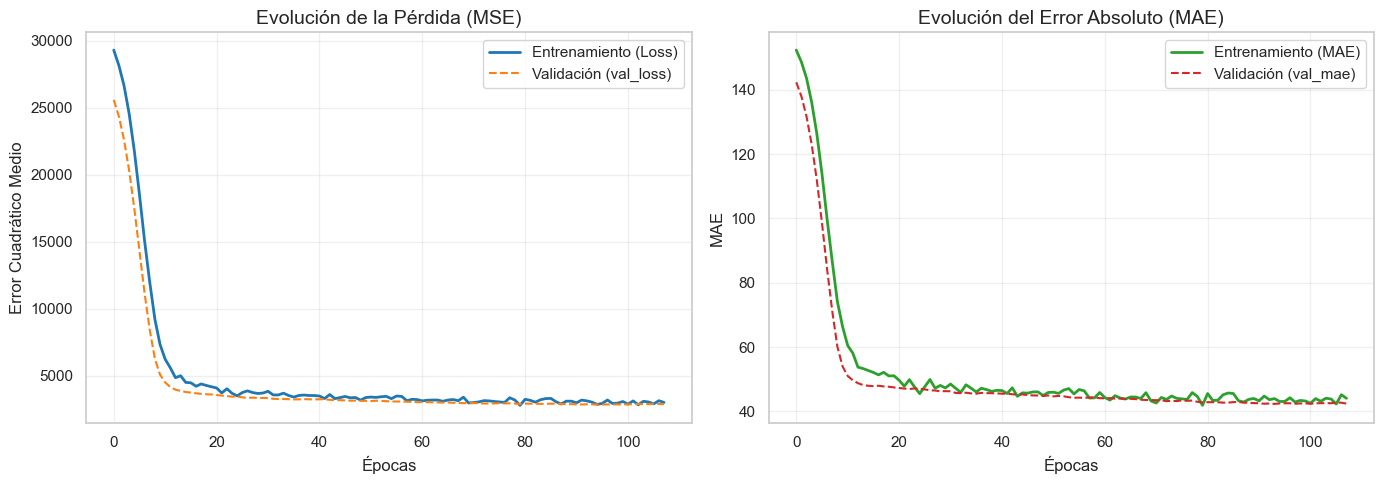

In [10]:
# Crear una figura con dos subgráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Pérdida (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Entrenamiento (Loss)", color="#1f77b4", linewidth=2)
plt.plot(history.history["val_loss"], label="Validación (val_loss)", color="#ff7f0e", linestyle='--')
plt.title("Evolución de la Pérdida (MSE)", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Error Cuadrático Medio")
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Error Absoluto Medio (MAE)
plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Entrenamiento (MAE)", color="#2ca02c", linewidth=2)
plt.plot(history.history["val_mae"], label="Validación (val_mae)", color="#d62728", linestyle='--')
plt.title("Evolución del Error Absoluto (MAE)", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

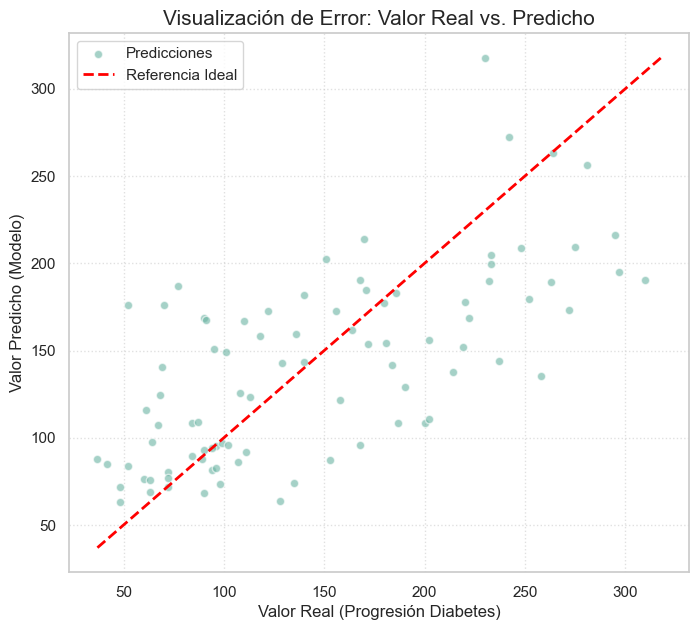

In [11]:
plt.figure(figsize=(8, 7))

# Gráfico de dispersión con transparencia (alpha) para ver densidad
plt.scatter(y_val, y_pred, alpha=0.6, color='#69b3a2', edgecolors='white', label='Predicciones')

# Línea de identidad (Ideal: Real == Predicho)
max_val = max(max(y_val), max(y_pred))
min_val = min(min(y_val), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Referencia Ideal')

plt.title("Visualización de Error: Valor Real vs. Predicho", fontsize=15)
plt.xlabel("Valor Real (Progresión Diabetes)", fontsize=12)
plt.ylabel("Valor Predicho (Modelo)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [12]:
# Seleccionamos los primeros 10 ejemplos para comparar
n_ejemplos = 10

print(f"{'REAL':>10} | {'PREDICHO':>10} | {'DIFERENCIA':>12} | {'ERROR %':>10}")
print("-" * 55)

for i in range(n_ejemplos):
    real = y_val[i]
    pred = y_pred[i]
    diff = pred - real
    pct_error = (abs(diff) / real) * 100

    # Formateo de colores básico para Colab (opcional pero visual)
    print(f"{real:10.2f} | {pred:10.2f} | {diff:+12.2f} | {pct_error:9.2f}%")

# Resumen final de confianza
print("-" * 55)
print(f"Promedio de error porcentual en estos casos: {np.mean(np.abs(y_pred[:n_ejemplos] - y_val[:n_ejemplos])/y_val[:n_ejemplos])*100:.2f}%")

      REAL |   PREDICHO |   DIFERENCIA |    ERROR %
-------------------------------------------------------
    219.00 |     151.82 |       -67.18 |     30.68%
     70.00 |     176.22 |      +106.22 |    151.74%
    202.00 |     156.07 |       -45.93 |     22.74%
    230.00 |     317.82 |       +87.82 |     38.18%
    111.00 |      91.55 |       -19.45 |     17.52%
     84.00 |     108.65 |       +24.65 |     29.35%
    242.00 |     272.18 |       +30.18 |     12.47%
    272.00 |     172.95 |       -99.05 |     36.41%
     94.00 |      81.61 |       -12.39 |     13.18%
     96.00 |      95.24 |        -0.76 |      0.80%
-------------------------------------------------------
Promedio de error porcentual en estos casos: 35.31%


In [13]:
import joblib # Librería estándar para guardar objetos de Python

# 1. Guardar el modelo de Keras (Estructura + Pesos)
model.save('modelo_diabetes_v1.keras')

# 2. Guardar el Escalador (¡Fundamental!)
# Si no guardas el scaler, no podrás procesar nuevos datos en el futuro
joblib.dump(scaler, 'scaler_diabetes.pkl')

# 3. Guardar las métricas en un archivo CSV para registro histórico
resumen_metricas = pd.DataFrame({
    'Metrica': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Valor': [mae, mse, rmse, r2]
})
resumen_metricas.to_csv('metricas_modelo.csv', index=False)

print("✅ ¡Archivos guardados con éxito!")
print("- modelo_diabetes_v1.keras (La red neuronal)")
print("- scaler_diabetes.pkl (El normalizador de datos)")
print("- metricas_modelo.csv (Tus resultados)")

✅ ¡Archivos guardados con éxito!
- modelo_diabetes_v1.keras (La red neuronal)
- scaler_diabetes.pkl (El normalizador de datos)
- metricas_modelo.csv (Tus resultados)


In [14]:
# Definición de un modelo más robusto (Deep & Wide)
model_v2 = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),

    # Capa 1: Más neuronas para capturar interacciones complejas
    layers.Dense(128, activation="swish"),
    layers.BatchNormalization(), # Estabiliza el entrenamiento
    layers.Dropout(0.3),

    # Capa 2: Capa intermedia
    layers.Dense(64, activation="swish"),
    layers.Dropout(0.2),

    # Capa 3: Capa refinadora
    layers.Dense(32, activation="relu"),

    # Salida
    layers.Dense(1)
])

# Usaremos un optimizador con una Tasa de Aprendizaje específica
opt = keras.optimizers.Adam(learning_rate=0.005)

model_v2.compile(optimizer=opt, loss="mse", metrics=["mae"])

# Re-entrenamos con el mismo Early Stopping
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32, # Batch size más grande para estabilidad
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0 # Silencioso para comparar rápido
)

# Comparación rápida de métricas
loss_v2, mae_v2 = model_v2.evaluate(X_val, y_val, verbose=0)
print(f"📊 MAE Original: {mae:.2f}")
print(f"🚀 MAE Nuevo (v2): {mae_v2:.2f}")

if mae_v2 < mae:
    print("\n✅ ¡Victoria! El nuevo modelo es más preciso.")
else:
    print("\n❌ El modelo original era mejor. A veces 'más complejo' no significa 'mejor' en datos pequeños.")

📊 MAE Original: 42.36
🚀 MAE Nuevo (v2): 143.12

❌ El modelo original era mejor. A veces 'más complejo' no significa 'mejor' en datos pequeños.


In [15]:
# Definición de un modelo "Smart & Lean"
model_v3 = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),

    # Menos neuronas pero mejor conectadas
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),

    layers.Dense(16, activation="relu"),

    # Salida
    layers.Dense(1)
])

# Bajamos el learning rate drásticamente para ser precisos
# El valor original era 0.001, probaremos 0.0005
opt_fine = keras.optimizers.Adam(learning_rate=0.0005)

model_v3.compile(optimizer=opt_fine, loss="mse", metrics=["mae"])

# Entrenamos con paciencia
history_v3 = model_v3.fit(
    X_train, y_train,
    epochs=300, # Más épocas porque vamos más lento
    batch_size=8, # Batches pequeños para ver cada detalle
    validation_data=(X_val, y_val),
    callbacks=[early_stop], # El early stop nos salvará si falla
    verbose=0
)

# Comparación final
_, mae_v3 = model_v3.evaluate(X_val, y_val, verbose=0)
print(f"📊 MAE Original: {mae:.2f}")
print(f"🎯 MAE Nuevo (v3): {mae_v3:.2f}")

if mae_v3 < mae:
    print("\n✅ ¡Ahora sí! La sutileza le ganó a la fuerza bruta.")
else:
    print("\n🤔 Sigue siendo difícil superar al original. El modelo simple es muy fuerte aquí.")

📊 MAE Original: 42.36
🎯 MAE Nuevo (v3): 145.00

🤔 Sigue siendo difícil superar al original. El modelo simple es muy fuerte aquí.


In [16]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []

print("🚀 Iniciando Validación Cruzada (K-Fold)...")

fold = 1
for train_index, val_index in kf.split(X):
    # Dividir datos para este 'fold'
    X_t, X_v = X[train_index], X[val_index]
    y_t, y_v = y[train_index], y[val_index]

    # Escalar
    X_t = scaler.fit_transform(X_t)
    X_v = scaler.transform(X_v)

    # Usar la arquitectura original (que demostró ser la más estable)
    model_kf = keras.Sequential([
        layers.Dense(32, activation="relu", input_shape=(X_t.shape[1],)),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])

    model_kf.compile(optimizer="adam", loss="mse", metrics=["mae"])

    # Entrenamiento rápido
    model_kf.fit(X_t, y_t, epochs=60, batch_size=16, verbose=0)

    # Evaluar
    _, fold_mae = model_kf.evaluate(X_v, y_v, verbose=0)
    mae_scores.append(fold_mae)
    print(f"✅ Fold {fold}: MAE = {fold_mae:.2f}")
    fold += 1

print("-" * 30)
print(f"🏆 MAE Promedio Final: {np.mean(mae_scores):.2f} (+/- {np.std(mae_scores):.2f})")

🚀 Iniciando Validación Cruzada (K-Fold)...


c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 1: MAE = 42.79


c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 2: MAE = 46.09


...

✅ Fold 3: MAE = 48.23


c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 4: MAE = 46.57


c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 5: MAE = 42.30
------------------------------
🏆 MAE Promedio Final: 45.20 (+/- 2.28)


In [17]:
from sklearn.linear_model import LinearRegression

# 1. Entrenar una Regresión Lineal Clásica
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Predecir
y_pred_lr = lr_model.predict(X_val)

# 3. Calcular MAE
mae_lr = mean_absolute_error(y_val, y_pred_lr)

print(f"🧠 MAE Red Neuronal (Tu mejor modelo): {mae:.2f}")
print(f"📉 MAE Regresión Lineal Clásica:      {mae_lr:.2f}")

print("\n--- RESULTADO FINAL ---")
if mae < mae_lr:
    print("🏆 ¡La Inteligencia Artificial gana! El esfuerzo de las neuronas valió la pena.")
else:
    print("⚖️ ¡Empate técnico o gana la Estadística! En datos pequeños, lo simple suele mandar.")

🧠 MAE Red Neuronal (Tu mejor modelo): 42.36
📉 MAE Regresión Lineal Clásica:      42.79

--- RESULTADO FINAL ---
🏆 ¡La Inteligencia Artificial gana! El esfuerzo de las neuronas valió la pena.


In [18]:
def predecir_diabetes_paciente(datos_paciente):
    """
    Recibe una lista con los 10 valores fisiológicos.
    """
    # 1. Convertir a array de numpy y redimensionar para el modelo
    datos_array = np.array(datos_paciente).reshape(1, -1)

    # 2. ESCALAR los datos (Paso vital)
    # Usamos el scaler que entrenamos al principio
    datos_escalados = scaler.transform(datos_array)

    # 3. Realizar la predicción con el mejor modelo
    prediccion = model.predict(datos_escalados, verbose=0)

    return prediccion[0][0]

# --- PRUEBA CON UN PACIENTE INVENTADO ---
# Orden: age, sex, bmi, bp, s1, s2, s3, s4, s5, s6
paciente_x = [0.05, -0.04, 0.12, 0.08, -0.03, -0.01, -0.02, 0.04, 0.09, 0.01]

resultado = predecir_diabetes_paciente(paciente_x)

print("🩺 Análisis del Paciente Finalizado")
print("-" * 35)
print(f"Resultado Estimado de Progresión: {resultado:.2f}")
print("-" * 35)
print("Interpretación: Mientras más alto el número, mayor progresión de la enfermedad.")

🩺 Análisis del Paciente Finalizado
-----------------------------------
Resultado Estimado de Progresión: 337.52
-----------------------------------
Interpretación: Mientras más alto el número, mayor progresión de la enfermedad.


In [20]:
import sys
!{sys.executable} -m pip install gradio

     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     ---------------------------------------- 43.1/43.1 kB 1.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/90.6 kB ? eta -:--:--
     ---------------------------------------- 90.6/90.6 kB 5.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.2/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.2/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.4/42.9 MB 2.4 MB/s eta 0:00:19
    --------------------------------------- 0.6/42.9 MB 3.1 MB/s eta 0:00:14
    --------------------------------------- 0.8/42.9 MB 2.8 MB/s eta 0:00:16
    --------------------------------------- 0.8/42.9 MB 2.9 MB/s eta 0:00:15
    --------------------------------------- 1.0/42.9 MB 2.7 MB/s eta 0:00:16
   - -------------------------------------- 1.5/42.9 MB 2.9 MB/s eta 0:00:15
   - -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# 1. Instalar Gradio
import gradio as gr

# 2. Definir la función que conectará la interfaz con el modelo
def interfaz_prediccion(age, sex, bmi, bp, s1, s2, s3, s4, s5, s6):
    # Lista con los valores de los sliders
    datos = [age, sex, bmi, bp, s1, s2, s3, s4, s5, s6]

    # Usamos nuestra función de predicción ya creada
    resultado = predecir_diabetes_paciente(datos)

    return f"Progresión estimada: {resultado:.2f}"

# 3. Crear la interfaz con sliders
# Nota: Los rangos -0.2 a 0.2 son los típicos del dataset normalizado de sklearn
demo = gr.Interface(
    fn=interfaz_prediccion,
    inputs=[
        gr.Slider(-0.2, 0.2, label="Edad (Normalizada)"),
        gr.Radio([-0.044, 0.050], label="Sexo (Codificado)"),
        gr.Slider(-0.2, 0.2, label="IMC (BMI)"),
        gr.Slider(-0.2, 0.2, label="Presión Arterial (BP)"),
        gr.Slider(-0.2, 0.2, label="S1 (Suero 1)"),
        gr.Slider(-0.2, 0.2, label="S2"),
        gr.Slider(-0.2, 0.2, label="S3"),
        gr.Slider(-0.2, 0.2, label="S4"),
        gr.Slider(-0.2, 0.2, label="S5"),
        gr.Slider(-0.2, 0.2, label="S6"),
    ],
    outputs="text",
    title="🩺 Predictor de Progresión de Diabetes",
    description="Mueve los deslizadores para ver cómo afectan los factores a la progresión de la enfermedad."
)

# 4. Lanzar la aplicación
demo.launch(share=True)

c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3f1bdac2503da698ea.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import zipfile
import os
from google.colab import files

# Lista de archivos que hemos creado a lo largo del proyecto
archivos_a_guardar = [
    'modelo_diabetes_v1.keras',
    'scaler_diabetes.pkl',
    'metricas_modelo.csv'
]

# Crear un archivo ZIP
with zipfile.ZipFile('proyecto_diabetes_completo.zip', 'w') as zipf:
    for archivo in archivos_a_guardar:
        if os.path.exists(archivo):
            zipf.write(archivo)
            print(f"📦 Agregado: {archivo}")

print("\n✅ ¡Paquete listo! Iniciando descarga...")
files.download('proyecto_diabetes_completo.zip')

📦 Agregado: modelo_diabetes_v1.keras
📦 Agregado: scaler_diabetes.pkl
📦 Agregado: metricas_modelo.csv

✅ ¡Paquete listo! Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# -----------------------
# Modelo
# -----------------------
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scikeras.wrappers import KerasRegressor

def build_model(neurons1=32, neurons2=16, learning_rate=0.001):

    model = keras.Sequential([
        layers.Dense(neurons1, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(neurons2, activation="relu"),
        layers.Dense(1)
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

model = KerasRegressor(model=build_model, verbose=0)

# -----------------------
# Parámetros
# -----------------------
param_dist = {

    "model__neurons1": [16, 32, 64],
    "model__neurons2": [8, 16, 32],

    "batch_size": [8, 16, 32],
    "epochs": [50, 80, 100, 200],

    "model__learning_rate": [0.01, 0.001, 0.0005]
}

# -----------------------
# Random Search
# -----------------------
random = RandomizedSearchCV(

    estimator=model,
    param_distributions=param_dist,

    n_iter=10,
    cv=3,

    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

random.fit(X_train, y_train)

print("Mejores parámetros:")
print(random.best_params_)

# -----------------------
# Evaluación
# -----------------------
best_model = random.best_estimator_

y_pred = best_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\nResultados:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

c:\Users\cotec\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mejores parámetros:
{'model__neurons2': 8, 'model__neurons1': 16, 'model__learning_rate': 0.01, 'epochs': 50, 'batch_size': 16}

Resultados:
MAE: 42.011022332009304
RMSE: 52.187702115980244
R2: 0.4859421961802356
